In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully")

Libraries imported successfully


In [83]:
df = pd.read_csv("hospital_readmissions_30k.csv")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (30000, 12)

First 5 rows:
   patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0           1   74   Other         130/72          240  31.5      Yes   
1           2   46  Female         120/92          292  36.3       No   
2           3   89   Other         135/78          153  30.3       No   
3           4   84  Female         123/80          153  31.5       No   
4           5   32   Other         135/84          205  18.4       No   

  hypertension  medication_count  length_of_stay discharge_destination  \
0           No                 5               1      Nursing_Facility   
1           No                 4               3      Nursing_Facility   
2          Yes                 1               1                  Home   
3          Yes                 3              10                  Home   
4          Yes                 6               4      Nursing_Facility   

  readmitted_30_days  
0                Yes  
1                 No  
2    

In [84]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


In [85]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nReadmission counts:")
print(df["readmitted_30_days"].value_counts())

print("\nReadmission percentage:")
print(df["readmitted_30_days"].value_counts(normalize=True) * 100)

Dataset shape: (30000, 12)

Data types:
patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
dtype: object

Missing values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

Readmission counts:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64

Readmission percentage:
readmitted_30_days
No     87.753333
Yes    12.246667
Name: proportion, dtype: f

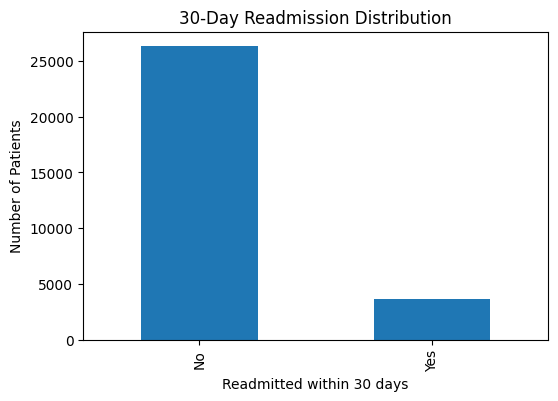

In [86]:
df["readmitted_30_days"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Patients")
plt.show()

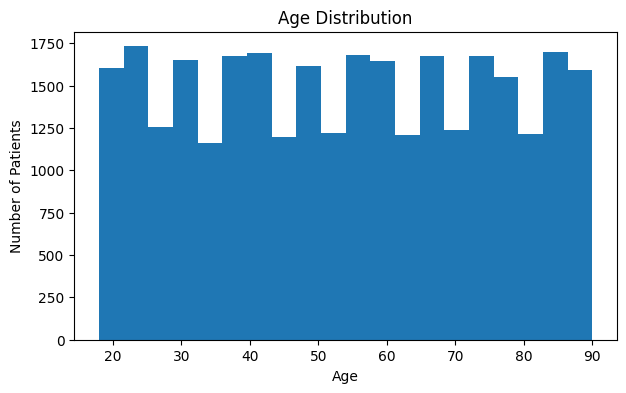

In [87]:
plt.figure(figsize=(7,4))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [88]:
# Convert target into 0 and 1
df["readmitted_30_days"] = df["readmitted_30_days"].map({
    "Yes": 1,
    "No": 0
})

print(df["readmitted_30_days"].value_counts())

readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


In [89]:
X = df.drop(columns=["readmitted_30_days"])
y = df["readmitted_30_days"]
X = X.drop(columns=["patient_id"])

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 10)
Target: (30000,)


In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
numeric_cols = [
    "age",
    "cholesterol",
    "bmi",
    "medication_count",
    "length_of_stay"
]

categorical_cols = [
    "gender",
    "blood_pressure",
    "diabetes",
    "hypertension",
    "discharge_destination"
]

Training data: (24000, 10)
Testing data: (6000, 10)


In [91]:
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [98]:
model = Pipeline([
    ("preprocessing", preprocessor),

    ("logistic_regression", LogisticRegression(
        penalty="l2",
        C=0.01,
        class_weight="balanced",
        max_iter=1000
    ))
])

model.fit(X_train, y_train)

print("Model trained successfully")
y_pred = model.predict(X_test)


y_prob = model.predict_proba(X_test)[:, 1]
print(y_pred)
print(y_prob)

Model trained successfully
[0 1 0 ... 0 0 1]
[0.48293417 0.56528803 0.43489557 ... 0.41473727 0.44151921 0.58372103]


In [93]:
roc_auc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("========== MODEL RESULTS ==========")

print("ROC-AUC   :", round(roc_auc, 4))
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))

========== MODEL RESULTS ==========
ROC-AUC   : 0.5633
Accuracy  : 0.6678
Precision : 0.1604
Recall    : 0.4041
F1 Score  : 0.2296


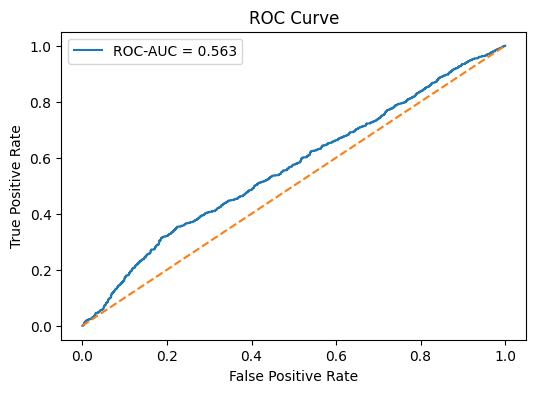

In [94]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))

plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Clinical Cost of Errors

False Negative:
A patient who is actually readmitted within 30 days is predicted as not being readmitted.
In a real hospital setting, this could mean missing a high-risk patient who may need closer follow-up after discharge.

False Positive:
A patient who is not readmitted within 30 days is predicted as high risk.
This could result in additional monitoring or healthcare resources being used unnecessarily.

Because of this, accuracy alone is not enough. Recall, precision and ROC-AUC are also important when evaluating the model.

In [95]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[3710 1555]
 [ 438  297]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.79      5265
           1       0.16      0.40      0.23       735

    accuracy                           0.67      6000
   macro avg       0.53      0.55      0.51      6000
weighted avg       0.80      0.67      0.72      6000



In [96]:
result = X_test.copy()

result["actual_readmission"] = y_test.values
result["predicted_readmission"] = y_pred
result["readmission_probability"] = y_prob

result.to_csv(
    "hospital_readmission_predictions.csv",
    index=False
)

print("Prediction file created successfully")

Prediction file created successfully


In [97]:
print("Case Study 1 done succesfully")

Case Study 1 done succesfully
